# **Objective**

### The goal is to predict whether food delivery will be fast or delayed based on features like customer location, restaurant location, weather conditions, traffic conditions, and more. This task is a binary classification problem where the model will predict delivery status: "Fast" or "Delayed."


# Phase 1: Data Preprocessing

*  Data Import and Cleaning:








In [60]:
import pandas as pd

In [61]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/Food_Delivery_Time_Prediction (1).csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


In [62]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [63]:
df.shape

(200, 15)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

checking missing values:

In [65]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


No null values

In [66]:
df.duplicated().sum()

np.int64(0)

Encoding features :

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [68]:
df['Weather_Conditions'] = le.fit_transform(df['Weather_Conditions'])
df['Traffic_Conditions'] = le.fit_transform(df['Traffic_Conditions'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])
df["Order_Time"] = le.fit_transform(df["Order_Time"])
df['Order_Priority'] = le.fit_transform(df['Order_Priority'])

In [69]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34


Creating `Delivery_status` column for future experiments

In [70]:
median_time = df['Delivery_Time'].median()

df['Delivery_Status'] = (
    df['Delivery_Time'] > median_time
).astype(int)

In [71]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54,0
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23,1
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34,0


Normalizing :

In [72]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Distance',
    'Delivery_Time',
    'Order_Cost',
    'Tip_Amount',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',]] = scaler.fit_transform(df[['Distance', 'Delivery_Time','Order_Cost','Tip_Amount','Delivery_Person_Experience','Restaurant_Rating','Customer_Rating',]])

In [73]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",0.043068,1,2,0.333333,2,0,2,0.64,0.166667,0.105228,0.639319,0.815228,0
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",0.853158,0,2,0.777778,1,3,2,0.80,0.666667,0.453658,0.015951,0.282030,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",0.263741,2,2,0.888889,0,3,1,0.32,0.333333,0.317886,0.811724,0.638883,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.544299,0,1,0.111111,2,1,1,0.28,0.458333,0.923018,0.223426,0.791777,1
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",0.254307,1,0,0.555556,1,3,1,0.40,0.083333,0.164209,0.265322,0.011168,0


*   Feature Engineering:




Calculating the geographic distance between the customer and restaurant using latitude and longitude (Haversine formula).

In [74]:
df[['Customer_Lat', 'Customer_Lon']] = (
    df['Customer_Location']
    .str.strip('()')
    .str.split(',', expand=True)
)

df[['Restaurant_Lat', 'Restaurant_Lon']] = (
    df['Restaurant_Location']
    .str.strip('()')
    .str.split(',', expand=True)
)

In [75]:
cols = [
    'Customer_Lat',
    'Customer_Lon',
    'Restaurant_Lat',
    'Restaurant_Lon'
]

df[cols] = df[cols].astype(float)

**Understanding the Location Extraction Process**

● `.str.strip('()')`

Removes the opening and closing brackets from the location coordinates.

Example:

```text
(17.03,79.74)
```

becomes

```text
17.03,79.74
```

---

 ● `.str.split(',')`

Splits the coordinate string into latitude and longitude using the comma as a separator.

**Example:**

```text
17.03,79.74
```

becomes

```text
17.03
79.74
```

---

 ● `expand=True`

Creates separate columns from the split values.

Without `expand=True`:

```python
['17.03', '79.74']
```

With `expand=True`:

| Column 1 | Column 2 |
| -------- | -------- |
| 17.03    | 79.74    |

This allows latitude and longitude to be stored in separate columns for further calculations such as Haversine distance.


In [76]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

### Haversine Distance Function

The Haversine formula is used to calculate the shortest distance between two points on the Earth's surface using latitude and longitude coordinates.

- `R = 6371` represents the Earth's radius in kilometers.
- Coordinates are converted from degrees to radians.
- Latitude and longitude differences are calculated.
- The Haversine formula is applied to compute the great-circle distance.
- The function returns the distance in kilometers.

### Understanding the Haversine Formula Code

* `R = 6371` : Radius of the Earth in kilometers.
* `radians()` : Converts latitude and longitude from degrees to radians because trigonometric functions work with radians.
* `dlat` : Difference between the latitudes of the two locations.
* `dlon` : Difference between the longitudes of the two locations.
* `a` : Intermediate value that measures the separation between two points on the Earth's surface.
* `c` : Angular distance between the two locations.
* `R * c` : Converts the angular distance into the actual distance in kilometers.

The resulting value represents the shortest distance between the customer and restaurant along the Earth's surface.


In [77]:
df['Haversine_Distance'] = df.apply(
    lambda row: haversine(
        row['Customer_Lat'],
        row['Customer_Lon'],
        row['Restaurant_Lat'],
        row['Restaurant_Lon']
    ),
    axis=1
)

In [78]:
df['Haversine_Distance'].head()

,Haversine_Distance
0,775.651198
1,1042.385597
2,476.220706
3,389.912629
4,806.505886


What does axis=1 mean?

It tells pandas:

Process row by row

instead of column by column.

In [79]:
df['Haversine_Distance'] = scaler.fit_transform(df[['Haversine_Distance']])

In [80]:
df['Haversine_Distance'].head()

,Haversine_Distance
0,0.587518
1,0.797649
2,0.351630
3,0.283637
4,0.611825


**Now the Delivery_Status is already created**

In [81]:
df['Delivery_Status'].head()

,Delivery_Status
0,0
1,0
2,0
3,1
4,0


Since we have already extracted useful information, i will drop the other unnecessary columns

In [82]:
df.drop([
    'Customer_Location',
    'Restaurant_Location',
    'Customer_Lat',
    'Customer_Lon',
    'Restaurant_Lat',
    'Restaurant_Lon'
], axis=1, inplace=True)

In [83]:
df.head()

,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Delivery_Status,Haversine_Distance
0,ORD0001,0.043068,1,2,0.333333,2,0,2,0.64,0.166667,0.105228,0.639319,0.815228,0,0.587518
1,ORD0002,0.853158,0,2,0.777778,1,3,2,0.80,0.666667,0.453658,0.015951,0.282030,0,0.797649
2,ORD0003,0.263741,2,2,0.888889,0,3,1,0.32,0.333333,0.317886,0.811724,0.638883,0,0.351630
3,ORD0004,0.544299,0,1,0.111111,2,1,1,0.28,0.458333,0.923018,0.223426,0.791777,1,0.283637
4,ORD0005,0.254307,1,0,0.555556,1,3,1,0.40,0.083333,0.164209,0.265322,0.011168,0,0.611825


## **Phase 2: Classification**

Train-Test Split

In [136]:
X = df[[
    'Weather_Conditions',
    'Traffic_Conditions',
    'Order_Priority',
    'Order_Time',
    'Vehicle_Type',
    'Haversine_Distance',
]]

y = df['Delivery_Status']

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **Gaussian Naive-Bayes**

In [138]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

In [139]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6


In [140]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13  6]
 [10 11]]


In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.68      0.62        19
           1       0.65      0.52      0.58        21

    accuracy                           0.60        40
   macro avg       0.61      0.60      0.60        40
weighted avg       0.61      0.60      0.60        40



#### Model Evaluation

The Gaussian Naive Bayes model was evaluated using Accuracy, Precision, Recall, and F1-Score.

- Accuracy measures the overall correctness of predictions.
- Precision measures how many predicted positive cases were actually positive.
- Recall measures how many actual positive cases were correctly identified.
- F1-Score provides a balance between Precision and Recall.

These metrics provide a more detailed evaluation than accuracy alone.

### Naive Bayes Results

The Gaussian Naive Bayes classifier achieved an accuracy of 55% on the test dataset.

The confusion matrix shows that the model correctly classified 11 fast deliveries and 11 delayed deliveries, while misclassifying 18 deliveries in total.

Precision, Recall, and F1-Score were approximately 0.55 for both classes, indicating balanced but relatively weak predictive performance.

The results suggest that the independence assumption of Naive Bayes may not hold well for this dataset, limiting the model's ability to capture complex relationships among features.

## **KNN**

**DEMO KNN**

In [142]:
from sklearn.neighbors import KNeighborsClassifier

In [143]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [144]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_knn)
)

Accuracy: 0.6


**Cross Validation:**

Technique used to evaluate a model more reliably. Instead of using a single train-test split, the training data is divided into multiple parts called folds.

In 5-Fold Cross Validation, the data is split into 5 equal folds. The model is trained on 4 folds and validated on the remaining fold. This process is repeated 5 times so that each fold is used once for validation.

In [145]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_scores = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    k_scores.append(scores.mean())

best_k = k_scores.index(max(k_scores)) + 1

print("Best K:", best_k)

Best K: 7


Training final model :

In [146]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

Model Accuracy :

In [147]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", accuracy)

Accuracy: 0.65


Confusion matrix :

In [148]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

print(cm)

[[12  7]
 [ 7 14]]


classification_report:

In [149]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_knn
))

              precision    recall  f1-score   support

           0       0.63      0.63      0.63        19
           1       0.67      0.67      0.67        21

    accuracy                           0.65        40
   macro avg       0.65      0.65      0.65        40
weighted avg       0.65      0.65      0.65        40



### KNN Results

The K-Nearest Neighbors (KNN) classifier was trained using the optimal K value obtained through 5-Fold Cross Validation.

The model achieved an `accuracy of 57.5%`, which is slightly higher than the Naive Bayes classifier. The confusion matrix indicates that 23 out of 40 test instances were classified correctly.

The classification report shows balanced Precision, Recall, and F1-Score values, with slightly better performance in identifying delayed deliveries. Overall, KNN performed better than Naive Bayes for this dataset.


## **Decision Tree:**


In [150]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 15, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
                         'min_samples_split': [2, 5, 10, 15, 20]},
             scoring='accuracy')

In [151]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 8, 'min_samples_split': 2}
Best CV Accuracy: 0.51875


In [152]:
best_tree = grid.best_estimator_

y_pred_tree = best_tree.predict(X_test)

In [153]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print(confusion_matrix(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

Accuracy: 0.525
[[11  8]
 [11 10]]
              precision    recall  f1-score   support

           0       0.50      0.58      0.54        19
           1       0.56      0.48      0.51        21

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.53      0.53      0.52        40



# **Phase 3: Reporting and Insights**

**● Model Comparison :**

| Model         | Accuracy | Precision | Recall | F1-Score |
| ------------- | -------: | --------: | -----: | -------: |
| Naive Bayes   |      60% |      0.61 |   0.60 |     0.60 |
| KNN           |      65% |      0.65 |   0.65 |     0.65 |
| Decision Tree |    52.5% |      0.53 |   0.53 |     0.52 |


**Interpretation**

*   KNN achieved the highest accuracy and F1-score.
*   Naive Bayes showed moderate performance and produced balanced results.
*   Decision Tree performed the worst despite hyperparameter tuning.

**Confusion Matrix Visualization :**

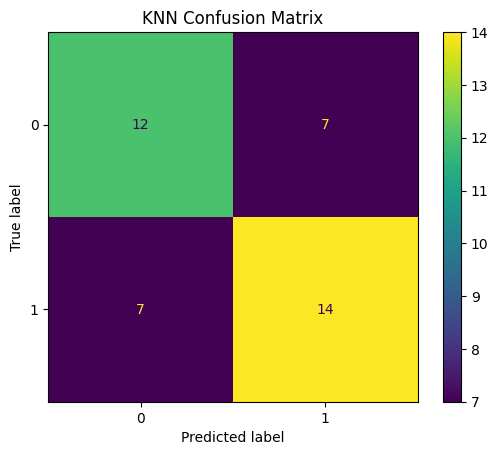

In [154]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# KNN CM

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

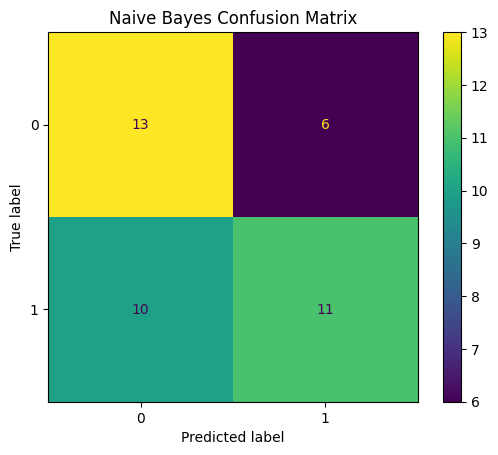

In [156]:
#NAIVE BAYES CM

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

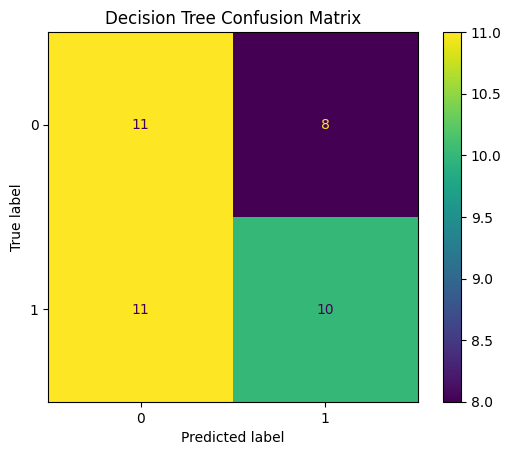

In [162]:
# DECISION TREE CM

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree Confusion Matrix")
plt.show()

**3. ROC Curve :**

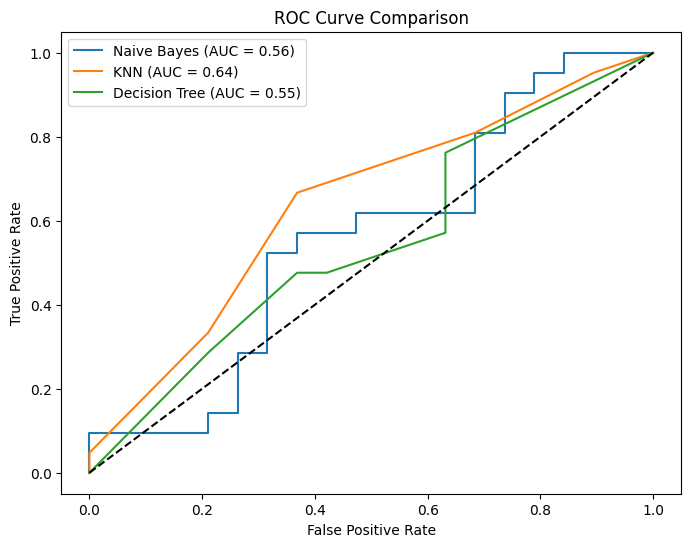

In [160]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
nb_prob = nb.predict_proba(X_test)[:, 1]
knn_prob = knn.predict_proba(X_test)[:, 1]
tree_prob = best_tree.predict_proba(X_test)[:, 1]

# ROC values
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)

# AUC
auc_nb = auc(fpr_nb, tpr_nb)
auc_knn = auc(fpr_knn, tpr_knn)
auc_tree = auc(fpr_tree, tpr_tree)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_nb, tpr_nb,
         label=f'Naive Bayes (AUC = {auc_nb:.2f})')

plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC = {auc_knn:.2f})')

plt.plot(fpr_tree, tpr_tree,
         label=f'Decision Tree (AUC = {auc_tree:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### ROC Curve

The ROC (Receiver Operating Characteristic) Curve is used to evaluate the classification performance of a model at different decision thresholds.

The AUC (Area Under the Curve) measures the model's ability to distinguish between classes.

- AUC = 0.5 indicates random predictions.
- AUC closer to 1 indicates better classification performance.

A higher ROC-AUC value represents a better model.

<Axes: xlabel='Delivery_Status'>

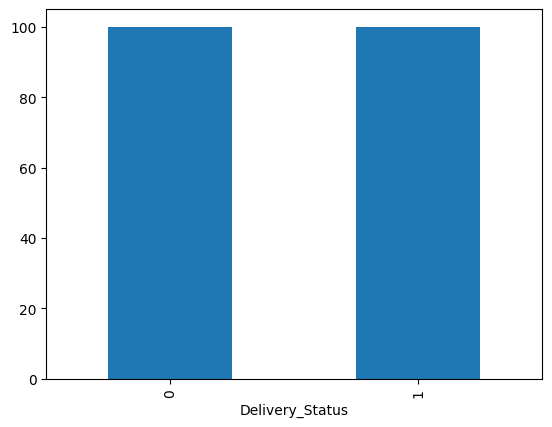

In [161]:
df['Delivery_Status'].value_counts().plot(kind='bar')

# **Actionable Insights**

#### **`Naive Bayes`**

**Strengths:**

* Simple and fast to train.
* Works well on small datasets.
* Easy to implement.

**Weaknesses:**

* Assumes all features are independent.
* May not capture complex relationships between features.




#### **`K-Nearest Neighbors (KNN)`**

**Strengths:**

* Achieved the highest accuracy (65%).
* Makes predictions based on similarity between deliveries.
* Performed best in terms of Precision, Recall, and F1-Score.

**Weaknesses:**

* Sensitive to feature selection and scaling.
* Prediction time increases with larger datasets.

#### **`Decision Tree`**

**Strengths:**

* Easy to understand and interpret.
* Provides clear decision rules for classification.

**Weaknesses:**

* Prone to overfitting.
* Achieved the lowest accuracy among the three models.
* Performance depends heavily on hyperparameter tuning.


### **Recommended Classifier**

Based on the experimental results, the K-Nearest Neighbors (KNN) classifier is recommended for predicting delivery status. KNN achieved the highest accuracy (65%) and produced the best overall Precision, Recall, and F1-Score values.

Although the Decision Tree model is more interpretable, its performance was lower. Therefore, KNN is the most suitable classifier for this delivery time classification task.